# Week 2 — CPG Exercises

**Prerequisites:** Make sure you have the latest code and dependencies:
```sh
cd cobar-2026
git pull
uv sync
```

## Exercise 1: Exploring CPG parameters

Use the interactive plot below to visualise a 3-oscillator CPG network. Adjust the parameters (intrinsic frequencies, amplitudes, coupling weights, phase biases, convergence coefficients, initial conditions) and observe how they affect the network dynamics.

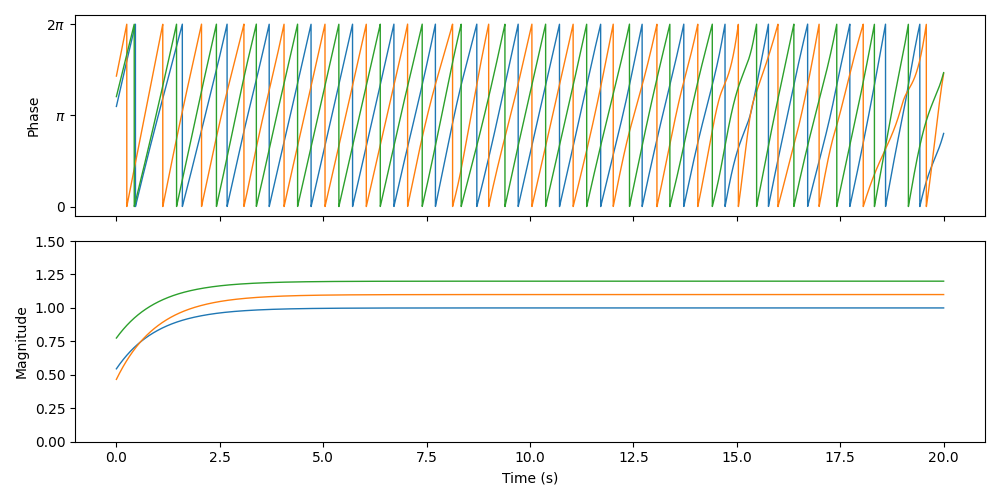

In [4]:
%matplotlib widget
from interactive_plot import interactive_plot

interactive_plot()

## Exercise 2: Hexapod gaits

Hexapods exhibit several canonical gaits. Here we implement three — **tripod**, **tetrapod**, and **wave** — by specifying different inter-leg phase bias matrices. Refer to [DeAngelis et al., 2019](https://elifesciences.org/articles/46409#s2-3) for detailed descriptions.

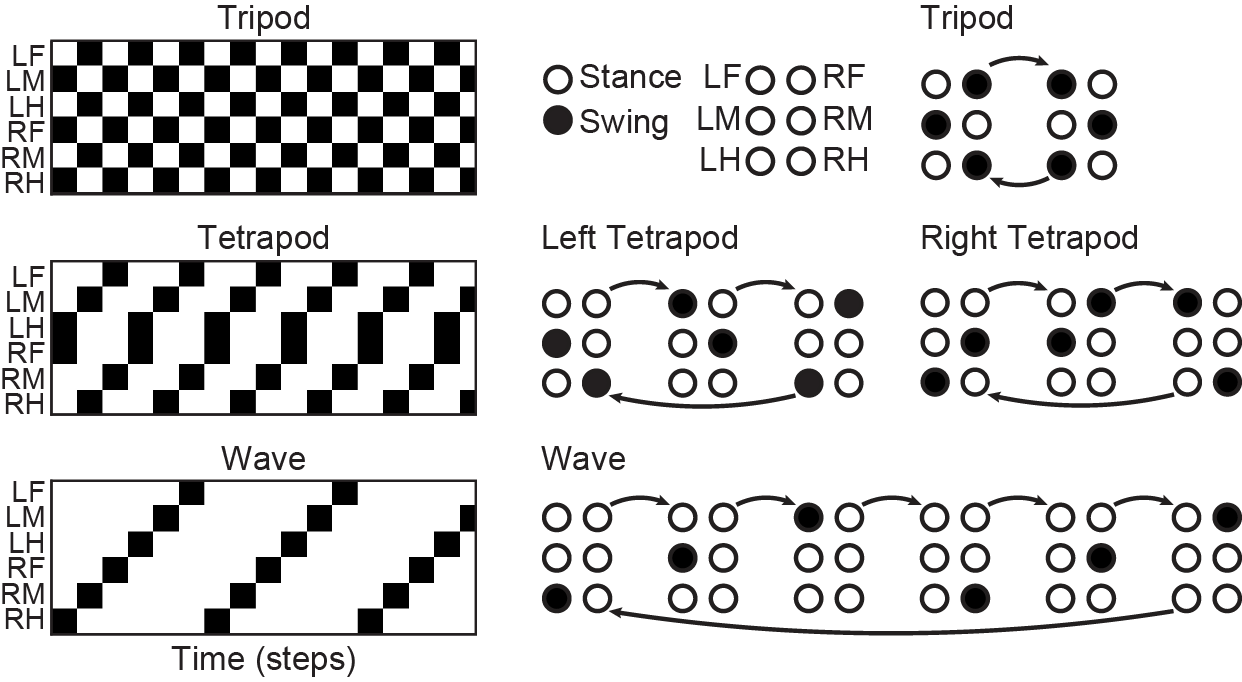

*(Adapted from [DeAngelis et al., 2019](https://doi.org/10.7554/eLife.46409))*

**TODO:** Fill in the phase bias matrices for the tetrapod and wave gaits below.

In [7]:
import numpy as np

tripod_phase_biases = np.pi * np.array(
    [
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
    ]
)

################################################################################
# TODO: fill in the phase biases for the tetrapod gait
tetrapod_phase_biases = np.array(
    [
        [0, 1, 2, 2, 0, 1],
        [2, 0, 1, 1, 2, 0],
        [1, 2, 0, 0, 1, 2],
        [1, 2, 0, 0, 1, 2],
        [0, 1, 2, 2, 0, 1],
        [2, 0, 1, 1, 2, 0],
    ]
) * (2 * np.pi / 3)

################################################################################

################################################################################
# TODO: fill in the phase biases for the wave gait
wave_phase_biases = np.array(
        [
        [0, 1, 2, 3, 4, 5],
        [5, 0, 1, 2, 3, 4],
        [4, 5, 0, 1, 2, 3],
        [3, 4, 5, 0, 1, 2],
        [2, 3, 4, 5, 0, 1],
        [1, 2, 3, 4, 5, 0],
    ]
) * (2 * np.pi / 6)
################################################################################

gait_phase_biases = {
    "tripod": tripod_phase_biases,
    "tetrapod": tetrapod_phase_biases,
    "wave": wave_phase_biases,
}

In [8]:
# Import the rest of the necessary utilities
from utils import (
    LEG_NAMES,
    DOFS_PER_LEG,
    load_preprogrammed_steps,
    get_control_signals,
    plot_gait_diagram,
    run_simulation,
    show_video,
)

step_data = load_preprogrammed_steps()

# Shared CPG parameters (same for all gaits — only phase_biases changes)
intrinsic_freqs = np.ones(6) * 12
intrinsic_amps = np.ones(6) * 1.0
convergence_coefs = np.ones(6) * 20
coupling_weights = np.array(
    [
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
    ]
) * 10.0

timestep = 1e-4
run_time = 1.0

In [9]:
def compute_leg_ap_positions(sim):
    """Step callback: compute each leg tip's anterior-posterior position relative to the body."""
    fly_name = next(iter(sim.world.fly_lookup))
    body = sim.mj_data.body(f"{fly_name}/")
    fly_pos = body.xpos
    # Extract the fly's forward direction from its quaternion
    w, x, y, z = body.xquat
    forward = np.array(
        [
            1.0 - 2.0 * (y * y + z * z),
            2.0 * (x * y + w * z),
            2.0 * (x * z - w * y),
        ]
    )
    leg_pos = np.array(
        [sim.mj_data.body(f"{fly_name}/{leg}_tarsus5").xpos for leg in LEG_NAMES]
    )
    # Project the leg positions onto the forward direction to get their anterior-posterior positions
    return (leg_pos - fly_pos) @ forward

In [10]:
# Close the previous figure and switch back to inline plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.close(plt.gcf())

100%|██████████| 10000/10000 [00:01<00:00, 9195.78it/s]


tripod This browser does not support the video tag.


100%|██████████| 10000/10000 [00:01<00:00, 9028.11it/s]


tetrapod This browser does not support the video tag.


100%|██████████| 10000/10000 [00:01<00:00, 9981.61it/s]


wave This browser does not support the video tag.


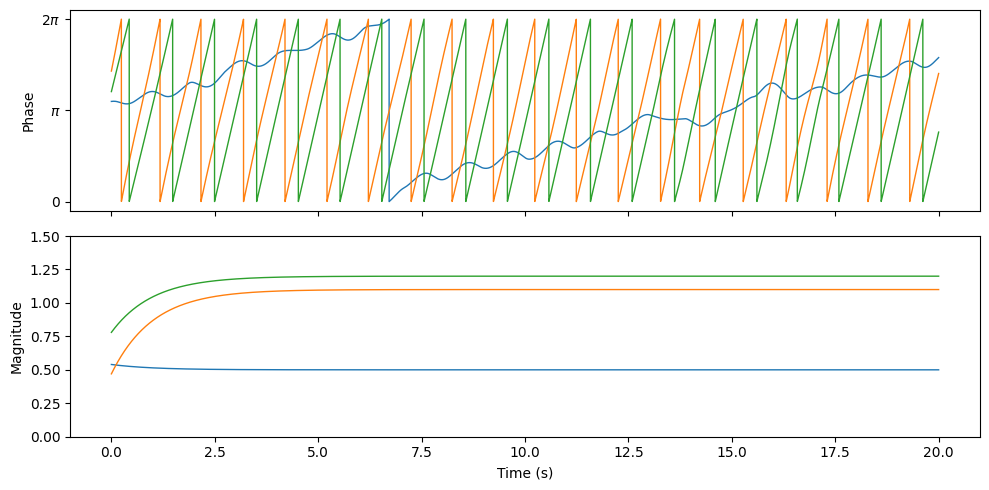

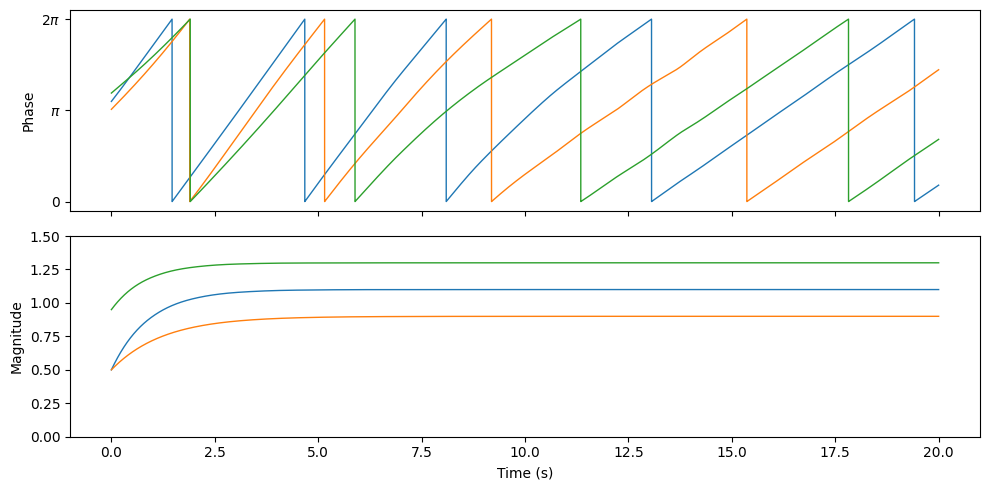

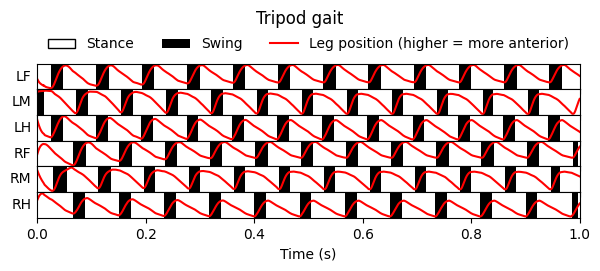

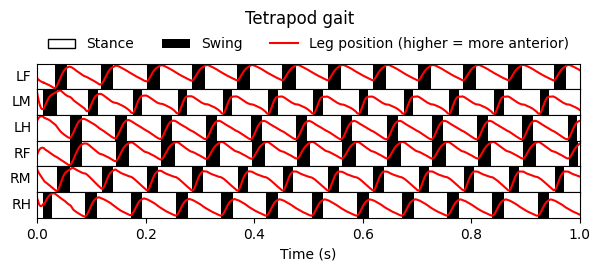

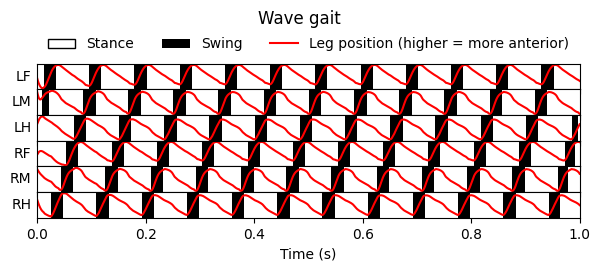

In [11]:
from flygym.utils.math import Rotation3D

# camera keyword arguments for top-down view of the fly
camera_kwargs = {
    "pos_offset": (0, 0, 10),
    "rotation": Rotation3D("xyaxes", (1, 0, 0, 0, 1, 0)),
    "mode": "fixed",
}

for gait_name, phase_biases in gait_phase_biases.items():
    joint_angles, adhesion_signals, dof_order = get_control_signals(
        step_data=step_data,
        phase_biases=phase_biases,
        intrinsic_freqs=intrinsic_freqs,
        intrinsic_amps=intrinsic_amps,
        convergence_coefs=convergence_coefs,
        coupling_weights=coupling_weights,
        timestep=timestep,
        run_time=run_time,
    )

    sim, leg_ap_data = run_simulation(
        joint_angles,
        dof_order,
        adhesion_signals=adhesion_signals,
        adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
        camera_kwargs=camera_kwargs,
        playback_speed=0.1,
        step_callback=compute_leg_ap_positions,
    )

    show_video(sim, title=gait_name)
    plot_gait_diagram(
        timestep=timestep, leg_ap_positions=np.array(leg_ap_data), title=gait_name
    )

## Exercise 3: Locomotion on complex terrain

So far the fly has been walking on a flat surface. In this exercise we test the CPG controller on a terrain with gaps.

**TODO:** Implement the `GappedTerrain` class below by adding box geoms with gaps in between. Refer to the [MuJoCo XML reference](https://mujoco.readthedocs.io/en/stable/XMLreference.html#body-geom) for the geom specification. The arena should look like this:

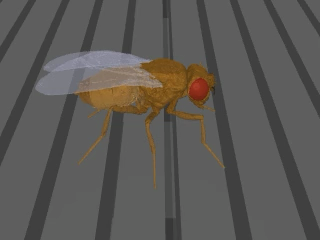

In [13]:
from flygym.compose.world import FlatGroundWorld


class GappedTerrain(FlatGroundWorld):
    """Flat ground with periodic gaps (missing floor strips).

    Parameters
    ----------
    x_range : (float, float)
        Spatial extent of the terrain in x (mm).
    y_range : (float, float)
        Spatial extent of the terrain in y (mm).
    gap_width : float
        Width of each gap (mm).
    block_width : float
        Width of each solid block between gaps (mm).
    gap_depth : float
        Depth of the gaps (mm).
    """

    def __init__(
        self,
        x_range: tuple[float, float] = (-10, 25),
        y_range: tuple[float, float] = (-20, 20),
        gap_width: float = 0.3,
        block_width: float = 1.0,
        gap_depth: float = 2.0,
        half_size: float = 1000,
    ):
        super().__init__(
            half_size=half_size,
            pos=(np.mean(x_range), np.mean(y_range), -gap_depth),
        )

        ########################################################################
        # TODO: create a terrain with gaps by adding box geoms for the ground
        # and leaving gaps in between. Refer to
        # https://mujoco.readthedocs.io/en/stable/XMLreference.html#body-geom
        # and the docstring at the top of this cell for the parameters you can 
        # use to create the terrain.

        # fill in the x positions of the centers of the blocks. Hint: use
        # np.arange with the appropriate start, stop, and step values to create
        # a sequence of block centers
        block_centers = np.arange(
            x_range[0] + block_width / 2,
            x_range[1],
            block_width + gap_width,
        )

        box_size = (
            block_width / 2,    # fill in the half-length of the blocks in x
            (y_range[1] - y_range[0]) / 2,
            gap_depth / 2,
        )
 
        for x_pos in block_centers:
            geom = self.mjcf_root.worldbody.add(
                "geom",
                type="box",
                name=f"ground_box_x{x_pos}",
                size=box_size,
                pos=(x_pos, 0, -gap_depth / 2),
            )
            self.ground_contact_geoms.append(geom)
        ########################################################################

In [14]:
world = GappedTerrain()

joint_angles, adhesion_signals, dof_order = get_control_signals(
    step_data=step_data,
    phase_biases=gait_phase_biases["tetrapod"],
    intrinsic_freqs=intrinsic_freqs,
    intrinsic_amps=intrinsic_amps,
    convergence_coefs=convergence_coefs,
    coupling_weights=coupling_weights,
    timestep=1e-4,
    run_time=1.0,
)

sim, _ = run_simulation(
    joint_angles,
    dof_order,
    adhesion_signals=adhesion_signals,
    adhesion_segments=[f"{leg}_tarsus5" for leg in LEG_NAMES],
    world=world,
)

100%|██████████| 10000/10000 [00:04<00:00, 2316.62it/s]


In [15]:
show_video(sim, title="Tetrapod gait on gapped terrain")

Tetrapod gait on gapped terrain This browser does not support the video tag.


**Question:** Does the CPG controller work well on the gapped terrain? If not, how could it be improved?

ANSWER: The CPG isnt made for gapped terrain as it is purely feedforward. Its not going to react to unexpected situations such as a leg geting traped. We need a hybrid control made with a CPG and sensory feedback (reflexes), so that a correction is made in the case of a leg getting trapped for example.